# Cash Bond, Curves, and RV

Set up a small mixed bond screen, build the rates curves, fit the credit RV line, and size a simple Treasury hedge.


In [45]:
from dataclasses import replace
from decimal import Decimal

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from fuggers_py.core import Currency, Date, Frequency, Price
from fuggers_py.core.daycounts import DayCountConvention
from fuggers_py.market.curves import DiscountCurveBuilder, ForwardCurve
from fuggers_py.measures.risk import BondRiskCalculator, dv01_hedge_ratio
from fuggers_py.measures.spreads import (
    BenchmarkSpec,
    DiscountMarginCalculator,
    GSpreadCalculator,
    GovernmentCurve,
    ISpreadCalculator,
    OASCalculator,
    ParParAssetSwap,
)
from fuggers_py.measures.yas import YASCalculator
from fuggers_py.measures.yields import current_yield_from_bond_pct
from fuggers_py.pricers.bonds import BondPricer
from fuggers_py.pricers.bonds.options import HullWhiteModel
from fuggers_py.products.bonds import SinkingFundBond, SinkingFundEntry, SinkingFundSchedule
from fuggers_py.reference import BondReferenceData, BondType, CallScheduleEntry, FloatingRateTerms, IssuerType, Tenor, YieldCalculationRules

ACT_365 = DayCountConvention.ACT_365_FIXED.to_day_count()

def dec(value: object) -> Decimal:
    return value if isinstance(value, Decimal) else Decimal(str(value))

def fmt_px(value: Decimal | float | None, digits: int = 3) -> str:
    return '' if value is None else f"{float(dec(value)):.{digits}f}"

def fmt_bp(value: Decimal | float | None, digits: int = 1) -> str:
    return '' if value is None else f"{float(dec(value)):.{digits}f}"


## Setup

Work with one Treasury, two bullet credits, one FRN, one callable, and one sinking-fund bond.


In [46]:
trade_date = Date.parse('2026-01-15')

treasury_id = 'UST_5Y_2031'
bullet_ids = ['ACME_5Y_2031', 'RIVER_8Y_2034']
frn_id = 'FLOATCO_3M_2029'
callable_id = 'CALLCO_6Y_2032'
sinking_id = 'SINKCO_7Y_2033'

display_universe_ids = [treasury_id, *bullet_ids, frn_id, callable_id, sinking_id]
credit_fit_ids = ['ACME_5Y_2031', 'METRO_4Y_2030', 'RIVER_8Y_2034', 'HARBOR_10Y_2036', 'NOVA_12Y_2038']
treasury_hedge_ids = ['UST_2Y_2028', 'UST_5Y_2031', 'UST_7Y_2033', 'UST_10Y_2036', 'UST_20Y_2046', 'UST_30Y_2056']

quotes = pd.read_csv('synthetic_data/bonds/cash_bond_market_levels.csv').set_index('instrument_id')
reference_rows = pd.read_csv('synthetic_data/bonds/instruments.csv', dtype=str, keep_default_na=False).set_index('instrument_id')
government_curve_quotes = pd.read_csv('synthetic_data/curves/nominal_government_curve.csv')
discount_curve_quotes = pd.read_csv('synthetic_data/curves/ois_discount_curve.csv')

call_schedule = (
    CallScheduleEntry(Date.parse('2029-01-15'), Decimal('101.0')),
    CallScheduleEntry(Date.parse('2030-01-15'), Decimal('100.5')),
    CallScheduleEntry(Date.parse('2031-01-15'), Decimal('100.0')),
)
sinking_schedule = SinkingFundSchedule.new(
    [
        SinkingFundEntry(Date.parse('2028-01-15'), Decimal('0.92')),
        SinkingFundEntry(Date.parse('2029-01-15'), Decimal('0.80')),
        SinkingFundEntry(Date.parse('2030-01-15'), Decimal('0.66')),
        SinkingFundEntry(Date.parse('2031-01-15'), Decimal('0.50')),
        SinkingFundEntry(Date.parse('2032-01-15'), Decimal('0.28')),
        SinkingFundEntry(Date.parse('2033-01-15'), Decimal('0.00')),
    ]
)


In [47]:
instrument_map = {}

fixed_rate_ids = sorted(
    set(display_universe_ids + credit_fit_ids + treasury_hedge_ids) - {frn_id, callable_id, sinking_id},
    key=lambda instrument_id: Date.parse(reference_rows.loc[instrument_id, 'maturity_date']),
)
for instrument_id in fixed_rate_ids:
    row = reference_rows.loc[instrument_id]
    instrument_map[instrument_id] = BondReferenceData(
        instrument_id=instrument_id,
        bond_type=BondType.FIXED_RATE,
        issuer_type=IssuerType.SOVEREIGN if row['sector'] == 'GOVERNMENT' else IssuerType.CORPORATE,
        issue_date=Date.parse(row['issue_date']),
        maturity_date=Date.parse(row['maturity_date']),
        currency=Currency.from_code(row['currency']),
        notional=dec(row['notional']),
        coupon_rate=dec(row['coupon_rate']),
        frequency=Frequency[row['frequency']],
        issuer_name=row['issuer'],
        sector=row['sector'],
        rating=row['rating'],
    ).to_instrument()

frn_row = reference_rows.loc[frn_id]
instrument_map[frn_id] = BondReferenceData(
    instrument_id=frn_id,
    bond_type=BondType.FLOATING_RATE,
    issuer_type=IssuerType.CORPORATE,
    issue_date=Date.parse(frn_row['issue_date']),
    maturity_date=Date.parse(frn_row['maturity_date']),
    currency=Currency.from_code(frn_row['currency']),
    notional=dec(frn_row['notional']),
    frequency=Frequency[frn_row['frequency']],
    floating_rate_terms=FloatingRateTerms(
        index_name=frn_row['index'],
        spread=dec(frn_row['quoted_spread']),
        reset_frequency=Frequency[frn_row['frequency']],
        current_reference_rate=dec(frn_row['current_reference_rate']),
    ),
    issuer_name=frn_row['issuer'],
    sector=frn_row['sector'],
    rating=frn_row['rating'],
).to_instrument()

callable_row = reference_rows.loc[callable_id]
instrument_map[callable_id] = BondReferenceData(
    instrument_id=callable_id,
    bond_type=BondType.CALLABLE,
    issuer_type=IssuerType.CORPORATE,
    issue_date=Date.parse(callable_row['issue_date']),
    maturity_date=Date.parse(callable_row['maturity_date']),
    currency=Currency.from_code(callable_row['currency']),
    notional=dec(callable_row['notional']),
    coupon_rate=dec(callable_row['coupon_rate']),
    frequency=Frequency[callable_row['frequency']],
    call_schedule=call_schedule,
    issuer_name=callable_row['issuer'],
    sector=callable_row['sector'],
    rating=callable_row['rating'],
).to_instrument()

sinking_row = reference_rows.loc[sinking_id]
instrument_map[sinking_id] = SinkingFundBond.new(
    issue_date=Date.parse(sinking_row['issue_date']),
    maturity_date=Date.parse(sinking_row['maturity_date']),
    coupon_rate=dec(sinking_row['coupon_rate']),
    frequency=Frequency[sinking_row['frequency']],
    sinking_schedule=sinking_schedule,
    currency=Currency.from_code(sinking_row['currency']),
    notional=dec(sinking_row['notional']),
    rules=replace(YieldCalculationRules.us_corporate(), frequency=Frequency[sinking_row['frequency']]),
)

settlement_map = {
    instrument_id: bond.rules().settlement_rules.settlement_date(trade_date, bond.rules().calendar.to_calendar())
    for instrument_id, bond in instrument_map.items()
}


## Curves

Build the government and discount curves, then fit the bullet-credit RV line.


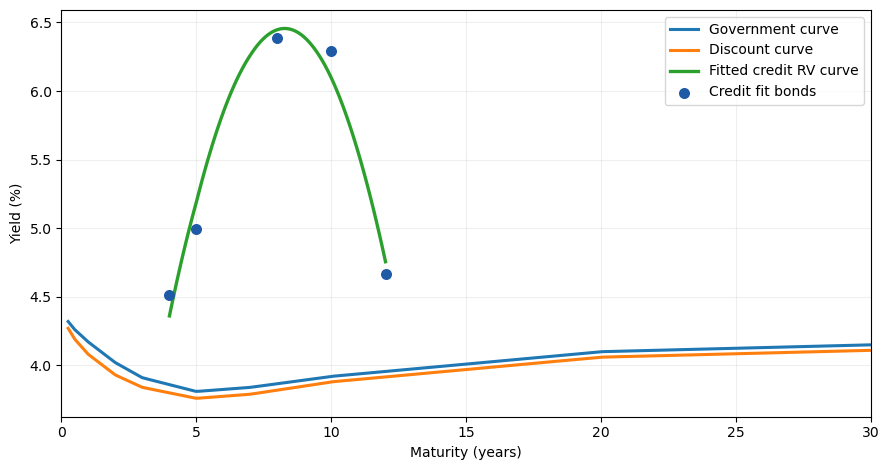

In [48]:
pricer = BondPricer()

government_curve = GovernmentCurve.us_treasury(trade_date)
for row in government_curve_quotes.to_dict('records'):
    government_curve.add_benchmark(Tenor.parse(row['tenor']), dec(row['value']))

discount_curve_builder = DiscountCurveBuilder(reference_date=trade_date)
for row in discount_curve_quotes.to_dict('records'):
    discount_curve_builder = discount_curve_builder.add_zero_rate(Tenor.parse(row['tenor']).to_years_approx(), dec(row['value']))
discount_curve = discount_curve_builder.build()
forward_curve = ForwardCurve.from_months(discount_curve, 3)

g_spread_calc = GSpreadCalculator(government_curve)
credit_fit_rows = []
for instrument_id in credit_fit_ids:
    bond = instrument_map[instrument_id]
    settlement_date = settlement_map[instrument_id]
    clean_price = dec(quotes.at[instrument_id, 'value'])
    ytm = pricer.yield_from_price(bond, Price.new(clean_price, bond.currency()), settlement_date).ytm
    credit_fit_rows.append(
        {
            'instrument_id': instrument_id,
            'maturity_years': float(ACT_365.year_fraction(trade_date, bond.maturity_date())),
            'ytm_pct': float(ytm.as_percentage()),
            'g_spread_bp': float(g_spread_calc.spread_bps(bond, ytm.value(), benchmark=BenchmarkSpec.interpolated())),
        }
    )

credit_fit_df = pd.DataFrame(credit_fit_rows).sort_values('maturity_years').reset_index(drop=True)
fit_coefficients = np.polyfit(credit_fit_df['maturity_years'], credit_fit_df['g_spread_bp'], deg=2)
credit_fit_df['fitted_g_spread_bp'] = np.polyval(fit_coefficients, credit_fit_df['maturity_years'])
credit_fit_df['residual_bp'] = credit_fit_df['g_spread_bp'] - credit_fit_df['fitted_g_spread_bp']

years = np.linspace(0.25, 30.0, 240)
fit_years = np.linspace(float(credit_fit_df['maturity_years'].min()), float(credit_fit_df['maturity_years'].max()), 120)

figure, axis = plt.subplots(figsize=(9.0, 4.8))
axis.plot(years, [100 * float(government_curve.interpolated_yield(year)) for year in years], linewidth=2.2, label='Government curve')
axis.plot(years, [100 * float(discount_curve.zero_rate(trade_date.add_days(int(round(365 * year)))).value()) for year in years], linewidth=2.2, label='Discount curve')
axis.plot(
    fit_years,
    [100 * float(government_curve.interpolated_yield(year)) + float(np.polyval(fit_coefficients, year)) / 100 for year in fit_years],
    linewidth=2.4,
    label='Fitted credit RV curve',
)
axis.scatter(credit_fit_df['maturity_years'], credit_fit_df['ytm_pct'], color='#1f5aa6', s=48, zorder=5, label='Credit fit bonds')
axis.set_xlabel('Maturity (years)')
axis.set_ylabel('Yield (%)')
axis.set_xlim(0, 30)
axis.grid(alpha=0.2)
axis.legend(title='')
plt.tight_layout()
plt.show()


## Main screen

Price the mixed universe and keep the main spread lens in one table.


In [49]:
i_spread_calc = ISpreadCalculator(discount_curve)
asw_calc = ParParAssetSwap(discount_curve)
dm_calc = DiscountMarginCalculator(forward_curve=forward_curve, discount_curve=discount_curve)
oas_calc = OASCalculator(HullWhiteModel(mean_reversion=Decimal('0.03'), volatility=Decimal('0.01'), term_structure=discount_curve))
yas_calc = YASCalculator(curve=discount_curve, government_curve=government_curve)

pricing_state = {}
pricing_rows = []
for instrument_id in display_universe_ids:
    row = reference_rows.loc[instrument_id]
    bond = instrument_map[instrument_id]
    settlement_date = settlement_map[instrument_id]
    quote_value = dec(quotes.at[instrument_id, 'value'])

    screen_row = {
        'instrument_id': instrument_id,
        'kind': row['instrument_kind'],
        'quote': f"{quotes.at[instrument_id, 'quote_field']} {fmt_px(quote_value)}",
        'clean_price': '',
        'dirty_price': '',
        'ytm': '',
        'ytw': '',
        'current_yield': '',
        'g_spread_bps': '',
        'i_spread_bps': '',
        'z_spread_bps': '',
        'asw_bps': '',
        'oas_bps': '',
        'discount_margin_bps': '',
    }

    state = {'bond': bond, 'settlement_date': settlement_date}
    if instrument_id == frn_id:
        dirty_price = quote_value
        clean_price = dirty_price - bond.accrued_interest(settlement_date, forward_curve=forward_curve)
        discount_margin = dm_calc.calculate(bond, dirty_price, settlement_date)
        state['dirty_price'] = dirty_price
        state['discount_margin_bps'] = discount_margin * Decimal('10000')
        screen_row['clean_price'] = fmt_px(clean_price)
        screen_row['dirty_price'] = fmt_px(dirty_price)
        screen_row['discount_margin_bps'] = fmt_bp(state['discount_margin_bps'])
    else:
        clean_price = quote_value
        ytm = pricer.yield_from_price(bond, Price.new(clean_price, bond.currency()), settlement_date).ytm
        dirty_price = pricer.price_from_yield(bond, ytm, settlement_date).dirty.as_percentage()
        state['dirty_price'] = dirty_price
        state['ytm'] = ytm
        screen_row['clean_price'] = fmt_px(clean_price)
        screen_row['dirty_price'] = fmt_px(dirty_price)
        screen_row['ytm'] = f"{float(ytm.as_percentage()):.2f}%"

        if instrument_id == callable_id:
            base_bond = bond.base_bond if hasattr(bond, 'base_bond') else bond
            ytw = dec(bond.yield_to_worst(clean_price, settlement_date))
            oas = oas_calc.calculate(bond, dirty_price, settlement_date)
            state['oas'] = oas
            screen_row['ytw'] = f"{float(ytw * Decimal('100')):.2f}%"
            screen_row['current_yield'] = f"{float(current_yield_from_bond_pct(base_bond, clean_price)):.2f}%"
            screen_row['oas_bps'] = fmt_bp(oas * Decimal('10000'))
        else:
            yas = yas_calc.calculate(bond, clean_price, settlement_date)
            state['yas'] = yas
            screen_row['current_yield'] = f"{float(yas.current_yield):.2f}%"
            screen_row['g_spread_bps'] = fmt_bp(yas.g_spread_bps)
            screen_row['i_spread_bps'] = fmt_bp(i_spread_calc.spread_bps(bond, ytm.value(), settlement_date))
            screen_row['z_spread_bps'] = fmt_bp(yas.z_spread_bps)
            if row['sector'] != 'GOVERNMENT' and instrument_id != sinking_id:
                screen_row['asw_bps'] = fmt_bp(asw_calc.calculate(bond, dirty_price, settlement_date) * Decimal('10000'))

    pricing_state[instrument_id] = state
    pricing_rows.append(screen_row)

pd.DataFrame(pricing_rows)


,instrument_id,kind,quote,clean_price,dirty_price,ytm,ytw,current_yield,g_spread_bps,i_spread_bps,z_spread_bps,asw_bps,oas_bps,discount_margin_bps
0,UST_5Y_2031,fixed_bond,clean_price 99.140,99.140,99.150,3.94%,,3.78%,13.1,18.1,13.3,,,
1,ACME_5Y_2031,fixed_bond,clean_price 101.120,101.120,101.193,4.99%,,5.19%,118.3,123.3,115.9,119.2,,
2,RIVER_8Y_2034,fixed_bond,clean_price 98.200,98.200,98.285,6.39%,,6.21%,252.0,256.7,246.5,250.1,,
3,FLOATCO_3M_2029,frn,dirty_price 100.090,100.028,100.090,,,,,,,,,14.4
4,CALLCO_6Y_2032,callable,clean_price 100.350,100.350,100.426,5.43%,4.82%,5.48%,,,,,179.4,
5,SINKCO_7Y_2033,sinking_fund,clean_price 99.550,99.550,99.617,4.84%,,4.82%,100.0,105.0,98.3,,,


## Risk and RV

Hedge the cheapest bullet credit with the nearest Treasury, then read the fitted RV residuals.


In [50]:
cheapest_credit_id = credit_fit_df.sort_values('residual_bp', ascending=False).iloc[0]['instrument_id']
hedge_instrument_id = min(
    treasury_hedge_ids,
    key=lambda instrument_id: abs(
        float(ACT_365.year_fraction(trade_date, instrument_map[instrument_id].maturity_date()))
        - float(ACT_365.year_fraction(trade_date, instrument_map[cheapest_credit_id].maturity_date()))
    ),
)

cheapest_ytm = pricer.yield_from_price(
    instrument_map[cheapest_credit_id],
    Price.new(dec(quotes.at[cheapest_credit_id, 'value']), instrument_map[cheapest_credit_id].currency()),
    settlement_map[cheapest_credit_id],
).ytm
cheapest_risk = BondRiskCalculator(
    bond=instrument_map[cheapest_credit_id],
    ytm=cheapest_ytm,
    settlement_date=settlement_map[cheapest_credit_id],
).all_metrics()
hedge_risk = BondRiskCalculator(
    bond=instrument_map[hedge_instrument_id],
    ytm=pricer.yield_from_price(
        instrument_map[hedge_instrument_id],
        Price.new(dec(quotes.at[hedge_instrument_id, 'value']), instrument_map[hedge_instrument_id].currency()),
        settlement_map[hedge_instrument_id],
    ).ytm,
    settlement_date=settlement_map[hedge_instrument_id],
).all_metrics()
hedge_ratio = dv01_hedge_ratio(cheapest_risk.dv01, hedge_risk.dv01)

risk_rows = []
for instrument_id in [treasury_id, *bullet_ids, callable_id, sinking_id]:
    row = reference_rows.loc[instrument_id]
    state = pricing_state[instrument_id]
    bond = state['bond']
    settlement_date = state['settlement_date']

    if instrument_id == callable_id:
        duration = oas_calc.effective_duration(bond, state['oas'], settlement_date)
        convexity = oas_calc.effective_convexity(bond, state['oas'], settlement_date)
        dv01 = duration * dec(state['dirty_price']) * Decimal('0.0001')
        risk_basis = 'OAS'
    else:
        risk = state['yas'].risk
        duration = risk.modified_duration
        convexity = risk.convexity
        dv01 = risk.dv01
        risk_basis = 'YTM'

    risk_rows.append(
        {
            'instrument_id': instrument_id,
            'kind': row['instrument_kind'],
            'risk_basis': risk_basis,
            'modified_duration': f'{float(duration):.4f}',
            'convexity': f'{float(convexity):.4f}',
            'dv01_per_100': fmt_px(dv01, 4),
        }
    )

print(f'Long {cheapest_credit_id} versus short {hedge_instrument_id} at about {float(hedge_ratio):.2f}x DV01-neutral notional per 100 par.')
pd.DataFrame(risk_rows)


Long HARBOR_10Y_2036 versus short UST_10Y_2036 at about 0.87x DV01-neutral notional per 100 par.


,instrument_id,kind,risk_basis,modified_duration,convexity,dv01_per_100
0,UST_5Y_2031,fixed_bond,YTM,4.5118,23.6431,0.0447
1,ACME_5Y_2031,fixed_bond,YTM,4.3438,22.3551,0.0440
2,RIVER_8Y_2034,fixed_bond,YTM,6.2223,47.3362,0.0612
3,CALLCO_6Y_2032,callable,OAS,2.7245,8.9813,0.0274
4,SINKCO_7Y_2033,sinking_fund,YTM,4.5176,25.8588,0.0450


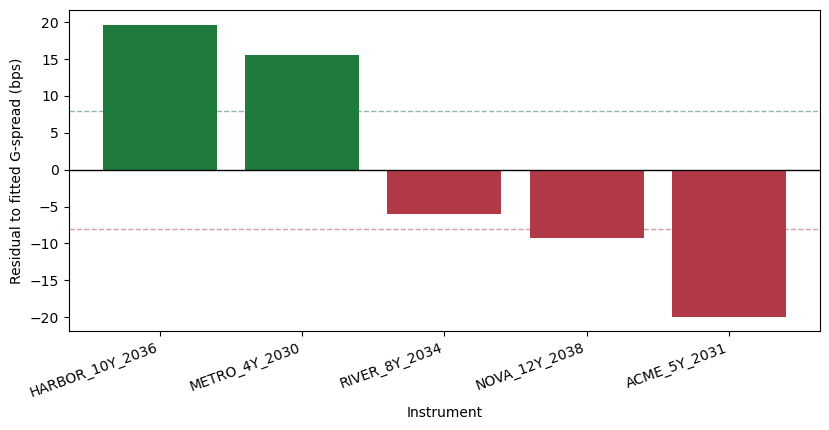

Cheapest credit: HARBOR_10Y_2036 at 19.7 bps.
Richest credit: ACME_5Y_2031 at -19.9 bps.


In [51]:
rv_threshold_bp = 8.0
rv_screen = credit_fit_df.sort_values('residual_bp', ascending=False).reset_index(drop=True).copy()
rv_screen['classification'] = np.where(
    rv_screen['residual_bp'] >= rv_threshold_bp,
    'CHEAP',
    np.where(rv_screen['residual_bp'] <= -rv_threshold_bp, 'RICH', 'NEUTRAL'),
)

figure, axis = plt.subplots(figsize=(8.4, 4.4))
axis.bar(
    rv_screen['instrument_id'],
    rv_screen['residual_bp'],
    color=['#1f7a3d' if value > 0 else '#b23a48' for value in rv_screen['residual_bp']],
)
axis.axhline(0.0, color='black', linewidth=1)
axis.axhline(rv_threshold_bp, color='#1f7a3d', linewidth=1, linestyle='--', alpha=0.5)
axis.axhline(-rv_threshold_bp, color='#b23a48', linewidth=1, linestyle='--', alpha=0.5)
axis.set_xlabel('Instrument')
axis.set_ylabel('Residual to fitted G-spread (bps)')
for tick in axis.get_xticklabels():
    tick.set_rotation(20)
    tick.set_ha('right')
plt.tight_layout()
plt.show()

print(
    f"Cheapest credit: {rv_screen.iloc[0]['instrument_id']} at {rv_screen.iloc[0]['residual_bp']:.1f} bps.\n"
    f"Richest credit: {rv_screen.iloc[-1]['instrument_id']} at {rv_screen.iloc[-1]['residual_bp']:.1f} bps."
)
